# Modelos de difusión para mercados financieros



Las partes del código que se deben completar estarán marcadas con un #TODO.

In [1]:
# Empecemos instalando los paquetes que vamos a utilizar
!pip install numpy pandas jax flax optax matplotlib seaborn scikit-learn yfinance diffrax

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.7/199.7 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.8/185.8 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.6/77.6 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 72.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.5/85.5 MB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.7/101.7 kB 8.4 MB/s eta 0:00:00
  Attempting uninstall: jaxlib
    Found existing installation: jaxlib 0.7.2
    Uninstalling jaxlib-0.7.2:
      Successfully uninstalled jaxlib-0.7.2
  Attempting uninstall: jax
    Found existing installation: jax 0.7.2
    Uninstalling jax-0.7.2:
      Successfully uninstalled jax-0.7.2


Los modelos de difusión son muy útiles para adaptar cualquier proceso de generación de datos, no solamente imágenes. En este taller mostraremos su flexibilidad en una aplicación financiera.

En mercados financieros es fundamental analizar el riesgo que suponen las inversiones que se tienen en un conjunto de activos. Por lo anterior, una de las tareas más importantes en la gerencia de riesgo financiero corresponde a simular escenarios del mercado de interés y analizar qué podría pasar en los peores días posibles de acuerdo con los datos históricos.

Tradicionalmente, este proceso de simulación se suele realizar utilizando métodos de montecarlo. Sin embargo, estos suelen ser computacionalmente demandantes, por lo cual los modelos generativos son útiles para acelerar estos simuladores.

Empecemos importando las librerías que vamos a utilizar para este taller:

In [2]:
from functools import partial
from typing import Dict

import jax
import jax.numpy as np
import flax.linen as nn
import optax

import pandas as pd
import yfinance as yf

from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
from tqdm import trange
import numpy as onp
import seaborn as sns

from matplotlib.gridspec import GridSpec

Para este caso, analizaremos el mercado global de ETFs, los cuales corrseponden a índices bursátiles que se transan en todo el mundo con la intención de poder hacer un análisis de riesgo del mercado globalmente.

En particular, contaremos con los siguientes ETFs:

- SPY (SPDR S&P 500 ETF Trust): sigue el índice S&P 500, representando las principales empresas de gran capitalización de Estados Unidos.
- QQQ (Invesco QQQ Trust): sigue el índice NASDAQ-100, compuesto principalmente por empresas tecnológicas y de crecimiento.
- IWM (iShares Russell 2000 ETF): representa empresas estadounidenses de pequeña capitalización (small caps).
- EFA (iShares MSCI EAFE ETF): agrupa acciones de mercados desarrollados fuera de Estados Unidos y Canadá, como Europa, Australia y Japón.
- EEM (iShares MSCI Emerging Markets ETF): representa acciones de mercados emergentes, incluyendo países como China, India, Brasil y México.
- TLT (iShares 20+ Year Treasury Bond ETF): sigue bonos del Tesoro de Estados Unidos con vencimientos superiores a 20 años.
- HYG (iShares iBoxx $ High Yield Corporate Bond ETF): representa bonos corporativos de alto rendimiento (high yield o bonos basura).
- GLD (SPDR Gold Shares): busca replicar el precio del oro físico.
- USO (United States Oil Fund): sigue el comportamiento del precio del petróleo (WTI) mediante contratos de futuros.
- VNQ (Vanguard Real Estate ETF): representa el mercado inmobiliario estadounidense mediante un portafolio de REITs (Real Estate Investment Trusts).

Además, para cada uno de estos ETF consideraremos tres características relevantes: retorno, volatilidad (intradía) y volumen transado en cada uno de los días.

In [3]:
tickers = [
    "SPY",
    "QQQ",
    "IWM",
    "EFA",
    "EEM",
    "TLT",
    "HYG",
    "GLD",
    "USO",
    "VNQ",
]
n_assets = len(tickers)
n_features = 3   # Retornos, volatilidad, volumen

data = yf.download(
    tickers,
    start="2014-01-01",
    end="2025-01-01",
    auto_adjust=True
)

# Precios de cierre
close = data["Close"]
# Retornos
returns = onp.log(close / close.shift(1))
# Volatilidad
volatility = (data["High"] - data["Low"]) / close
# Volumen
log_volume = onp.log(data["Volume"])


valid_index = (
    returns.notna().all(axis=1)
    & volatility.notna().all(axis=1)
    & log_volume.notna().all(axis=1)
)


returns = returns.loc[valid_index]
volatility = volatility.loc[valid_index]
log_volume = log_volume.loc[valid_index]


financial_data = np.array(
    onp.stack(
        [
            returns.values,
            volatility.values,
            log_volume.values,
        ],
        axis=-1,
    )
)

print(financial_data.shape)

[*********************100%***********************]  10 of 10 completed


(2767, 10, 3)


Veamos los histogramas para la distribucion de cada una de las características que estamos analizando de cada ETF.

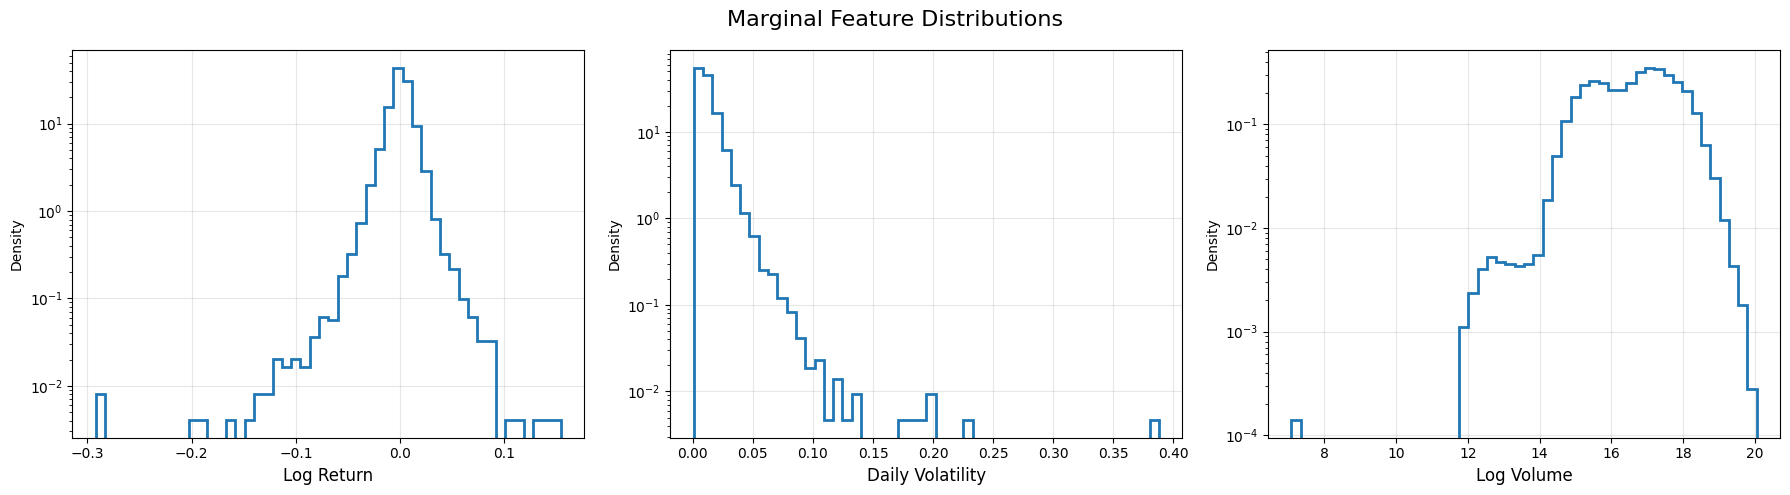

In [4]:
fig, ax = plt.subplots(ncols=3, figsize=(18, 5))


concat_data = financial_data.reshape(-1, n_features)

feature_names = [
    "Log Return",
    "Daily Volatility",
    "Log Volume"
]

for i in range(3):
    ax[i].hist(
        concat_data[:, i],
        bins=50,
        density=True,
        histtype="step",
        linewidth=2,
        label="Historical"
    )


    ax[i].set_xlabel(feature_names[i], fontsize=12)
    ax[i].set_ylabel("Density")
    ax[i].set_yscale("log")
    ax[i].grid(alpha=0.3)

plt.suptitle("Marginal Feature Distributions", fontsize=16)
plt.tight_layout()



In [5]:


mean_per_feature = financial_data.mean(axis=(0, 1))
std_per_feature = financial_data.std(axis=(0, 1))

normed_financial_data = (
    financial_data - mean_per_feature
) / std_per_feature


print("Means:", normed_financial_data.mean(axis=(0, 1)))
print("Standard deviations:", normed_financial_data.std(axis=(0, 1)))

Means: [-1.1029121e-09  8.1615497e-08 -6.5512978e-07]
Standard deviations: [0.99999994 1.         0.99999994]


## Forward diffusion

Primero analicemos el modelo de difusión que será la base de este tutorial. El principio fundamental de los modelos de difusión es añadir ruido progresivamente a la dos datos originales de la siguiente forma:

$q(z_t|z_{t-1}) = \mathcal{N}(z_t;\sqrt{\alpha_t} z_{t-1}, \beta_t)$

Donde la razón entre señal y ruido (signal to noise ratio) $SNR(t) = \alpha_t / \beta_t^2$ es estrictamente decreciente en cada iteración $t$. Lo anterior formaliza la idea de que $z_t$ cada vez tenga más ruido. La forma en la que $\beta_t$ cambia a través de las iteraciones lo llamaremos "variance schedule".

En este taller, trabajaremos una forma particular del modelo de difusión conocida como "variance-preserving", en la cual se establece la relación $\alpha_t = 1 - \beta_t$. Ahora, podemos obtener una iteración arbitraria $x_t$ a partir de $x_0$ de forma cerrada como se muestra a continuación:

$q(x_t|x_0) = \mathcal{N}(x_t;\sqrt{\bar{\alpha}_t}x_0, 1 - \bar{\alpha}_t)$

Donde $ \bar{\alpha}_t = \prod_{s=1}^t \alpha_s$

En las siguientes celdas podrán escribir el código necesario para llevar a cabo este proceso de difusión:

In [6]:
def beta_t(t: np.array,
           min_variance: float = 1e-4,
           max_variance: float = 0.02) -> np.array:
    """Linear variance schedule."""
    return min_variance + (max_variance - min_variance) * (t / 100.0)


def alpha_t(t: np.array,
            min_variance: float = 1e-4,
            max_variance: float = 0.02) -> np.array:
    """Variance-preserving schedule."""
    return 1.0 - beta_t(t, min_variance, max_variance)


def alpha_t_bar(t_n: int,
                t_N: int = 100,
                min_variance: float = 1e-4,
                max_variance: float = 0.02) -> float:
    """Cumulative product of alpha_t from t=0 to t=t_n."""
    times = np.arange(t_N + 1)
    alphas = alpha_t(times, min_variance, max_variance)
    alpha_bar = np.cumprod(alphas)
    return alpha_bar[t_n]


def forward_diffusion(x: np.array,
                      t_n: np.array,
                      t_N: int,
                      key: np.array) -> np.array:
    """Sample x_t directly from x_0."""
    eps = jax.random.normal(key, shape=x.shape)

    alpha_bar = jax.vmap(alpha_t_bar, in_axes=(0, None, None, None))(
        t_n, t_N, 1e-4, 0.02
    )

    alpha_bar = alpha_bar[None, None, :]          # (1,1,n_times)

    return (
        np.sqrt(alpha_bar) * x[:, :, None]
        + np.sqrt(1.0 - alpha_bar) * eps[:, :, None]
    )

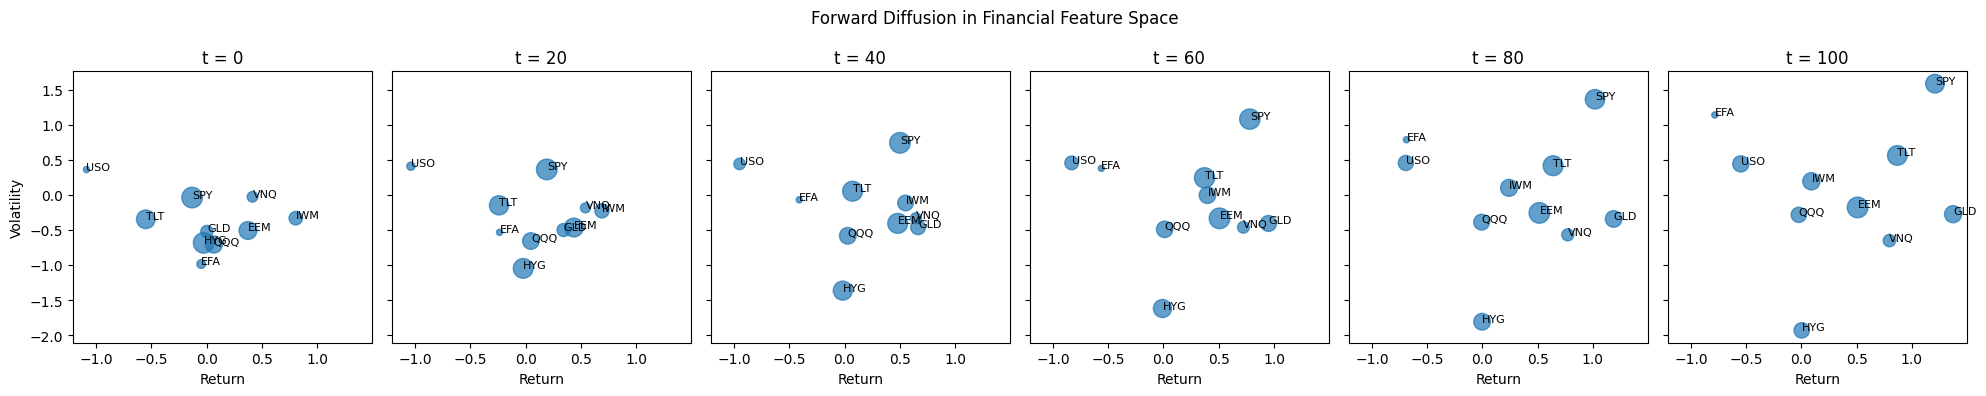

In [10]:
times = np.arange(0, 101, 20)

key = jax.random.PRNGKey(0)
t_N = 100

noisy_samples = forward_diffusion(
    normed_financial_data[0],
    times,
    t_N,
    key
)

fig, axes = plt.subplots(
    1,
    len(times),
    figsize=(20, 4),
    sharex=True,
    sharey=True
)

for i, t in enumerate(times):

    sample = noisy_samples[:, :, i]

    returns = sample[:, 0]
    volatility = sample[:, 1]
    volume = sample[:, 2]




    sizes = 200 * (volume - volume.min()) / (
        volume.max() - volume.min() + 1e-8
    ) + 20


    axes[i].scatter(
        returns,
        volatility,
        s=sizes,
        alpha=0.7
    )

    # Label each asset
    for x, y, label in zip(returns, volatility, tickers):
        axes[i].text(
            x,
            y,
            label,
            fontsize=8
        )

    axes[i].set_title(f"t = {t}")
    axes[i].set_xlabel("Return")

axes[0].set_ylabel("Volatility")

plt.suptitle("Forward Diffusion in Financial Feature Space")
plt.tight_layout()
plt.show()

## Eliminando el ruido del proceso de difusión
Ahora, entrenemos una red neuronal que aprenda a eliminar el ruido del proceso de difusión.

Para hacer esto, ela función de pérdida está definida por:

$L(x) = \langle w(t) || \epsilon - \hat{\epsilon}_\theta(x_t,t)|| \rangle $

Donde $\epsilon$ es el ruido que verdaderamente se agregó en el proceso y $hat{\epsilon}_\theta(x_t,t)$ es el ruido que se estima con la red neuronal. Dependiendo del peso $w(t)$ que escojamos, la función de pérdida será máxima verosimilitud o máxima verosimilitud con diferentes niveles de ruido. Por ahora, implementaremos un modelo de difusión simple con $w(t)=1$.

Para este ejemplo, la arquitectura de red neuronal que implementaremos será un multilayer perceptron. Sin embargo, pueden intentar diferentes arquitectura y ver esto cómo afecta el resultado del taller, por ejemplo, utilizando una red neuronal basada en grafos.

In [ ]:
# let's flatten the particle data to work with an MLP
# Flatten each trading day into a single vector
flattened_financial_data = normed_financial_data.reshape(
    len(normed_financial_data),
    -1
)
class MLP(nn.Module):
    """ A simple MLP in Flax. This is the noise-prediction network.
    """
    hidden_dim: int = 32
    out_dim: int = 2
    n_layers: int = 2

    @nn.compact
    def __call__(self, x):
        for _ in range(self.n_layers):
            x = nn.Dense(features=self.hidden_dim)(x)
            x = nn.gelu(x)
        x = nn.Dense(features=self.out_dim)(x)
        return x

noise_prediction_nn = MLP(hidden_dim=1024, out_dim=n_assets*n_features, n_layers=5)

# the noise prediction neural network will take as input an array of features per particle,
# of shape (n_particles*n_features,) and the diffusion time t, and return the predicted noise
# at that time step

# Let's initialize the network with some random data, of size 10
t_n = np.arange(10)[:, None]

params = noise_prediction_nn.init(
    key,
    np.concatenate(
        [
            flattened_financial_data[:10],
            t_n / t_N
        ],
        axis=-1
    )
)


In [ ]:
# Now let's define the loss function

def weight(t):
    return 1.


@partial(jax.jit, static_argnums=(3,))
def loss_fn(params: Dict, x: np.array, t_n: np.array, noise_prediction_nn: "nn.Module", key: np.array)->float:
    """ Loss function for the diffusion model

    Args:
        params (Dict): parameters of the noise prediction neural network
        x (np.array): point cloud data
        t_n (np.array): time steps to evaluate the diffusion model at
        noise_prediction_nn (nn.Module): noise prediction neural network
        key (np.array): jax random key

    Returns:
        float: reconstruction error loss
    """
    # sample some noise
    eps = jax.random.normal(key, shape=x.shape)
    alpha_t_bar_array = jax.vmap(alpha_t_bar, in_axes=(0,None,None,None))(t_n, t_N, 1e-4, 0.02)
    x_t = np.sqrt(alpha_t_bar_array) * x + np.sqrt(1 - alpha_t_bar_array) * eps
    eps_pred = noise_prediction_nn.apply(
    params,
    np.concatenate([x_t, t_n / t_N], axis=-1)
)
    return weight(t_n / t_N) * np.mean((eps - eps_pred) ** 2)


Ahora entrenemos el modelo.

In [ ]:
opt = optax.adam(learning_rate=3e-4)
opt_state = opt.init(params)

In [ ]:
n_steps = 5_000
n_batch = 128
t_N = 100

with trange(n_steps) as steps:
    for step in steps:

        # Sample a random mini-batch of trading days
        key, subkey = jax.random.split(key)

        idx = jax.random.choice(
            key,
            len(flattened_financial_data),
            shape=(n_batch,)
        )

        x_batch = flattened_financial_data[idx]

        # Sample a random diffusion time for each trading day
        t_n_batch = jax.random.choice(
            key,
            t_N,
            shape=(x_batch.shape[0], 1)
        )

        # Compute loss and gradients
        loss, grads = jax.value_and_grad(loss_fn)(
            params,
            x_batch,
            t_n_batch,
            noise_prediction_nn,
            key,
        )

        # Gradient update
        updates, opt_state = opt.update(grads, opt_state, params)
        params = optax.apply_updates(params, updates)

        steps.set_postfix(loss=float(loss))

100%|██████████| 5000/5000 [14:09<00:00,  5.89it/s, loss=0.4]


## Generando muestras

Para generar muestras a partir de ruido utilizaremos el concepto de "ancestral sampling", el cual utiliza como punto de partida la generación de una variable aleatoria normal estándar (la llamaremos prior) y de manera autorregresiva reconstruiremos el proceso de difusión de la siguiente forma:

$x_{t-1} = \frac{1}{\sqrt{\alpha_t}} \left( x_t - \frac{\beta_t}{\sqrt{1-\bar{\alpha}_t}} \hat{\epsilon}_\theta (x_t, t) \right) + \sigma_t z $

Donde $z \sim \mathcal{N}(0,1)$ y $\sigma_t^2 = \frac{1 - \bar{\alpha}_{t-1}}{1 - \bar{\alpha}_t} \beta_t$

In [ ]:
def generate_single_sample(noise_prediction_nn, params, key, t_N=100,):
    x_t = jax.random.normal(key, (n_assets*n_features,))

    for t_i in range(t_N, 0, -1):
        key, _ = jax.random.split(key)
        z = jax.random.normal(key, shape=x_t.shape)

        t = (t_i / t_N)
        t = np.atleast_1d(t)
        eps_pred = noise_prediction_nn.apply(
    params,
    np.concatenate([x_t[None, :], t.reshape(1, 1)], axis=-1)
)[0]#TODO: implement the call to the noise prediction neural network, with the correct input
        alpha = alpha_t(t_i)
        alpha_bar = alpha_t_bar(t_i)
        alpha_bar_prev = alpha_t_bar(t_i - 1)
        beta = beta_t(t_i)
        sigma_t = np.sqrt(
    ((1 - alpha_bar_prev) /
     (1 - alpha_bar))
    * beta
)#TODO: compute the sigma_t value, as described above

        x_t = (
    (1 / np.sqrt(alpha))
    * (
        x_t
        - (beta / np.sqrt(1 - alpha_bar))
        * eps_pred
    )
    + sigma_t * z
)#TODO: implement ancestral sampling

    return x_t


key = jax.random.PRNGKey(42)
single_sample = generate_single_sample(noise_prediction_nn, params, key, t_N=100,)

,Return,Volatility,Log Volume
SPY,-0.3093,-0.0958,1.0857
QQQ,-0.1643,-0.0549,0.1400
IWM,0.2364,0.1306,-0.6903
EFA,-0.0725,-0.5852,0.5020
EEM,0.8461,-0.0749,-0.3819
TLT,0.7648,0.1389,0.8711
HYG,0.3959,-0.2656,1.0794
GLD,0.2730,0.0315,-0.6251
USO,0.2680,0.6701,-1.4123
VNQ,-0.1220,0.5767,-1.3203


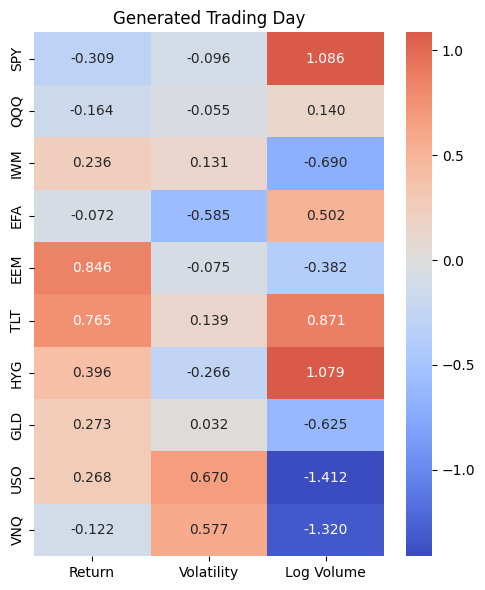

In [ ]:
x_sample = single_sample.reshape((n_assets, n_features))



feature_names = ["Return", "Volatility", "Log Volume"]

sample_df = pd.DataFrame(
    x_sample,
    index=tickers,
    columns=feature_names
)

display(sample_df.round(4))

plt.figure(figsize=(5,6))

sns.heatmap(
    sample_df,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".3f"
)

plt.title("Generated Trading Day")
plt.tight_layout()
plt.show()

In [ ]:
# Now let's vectorize this to draw lots of samples at once super fast
sample_fn = partial(generate_single_sample, noise_prediction_nn, params, t_N=50)

n_samples = 1000
sample_key = jax.random.split(key, n_samples)
x_samples = jax.vmap(sample_fn)(sample_key)
x_samples = x_samples.reshape((n_samples, n_assets, n_features))
#x_samples = x_samples * std_per_feature + mean_per_feature

/tmp/ipykernel_1954/2108089111.py:25: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


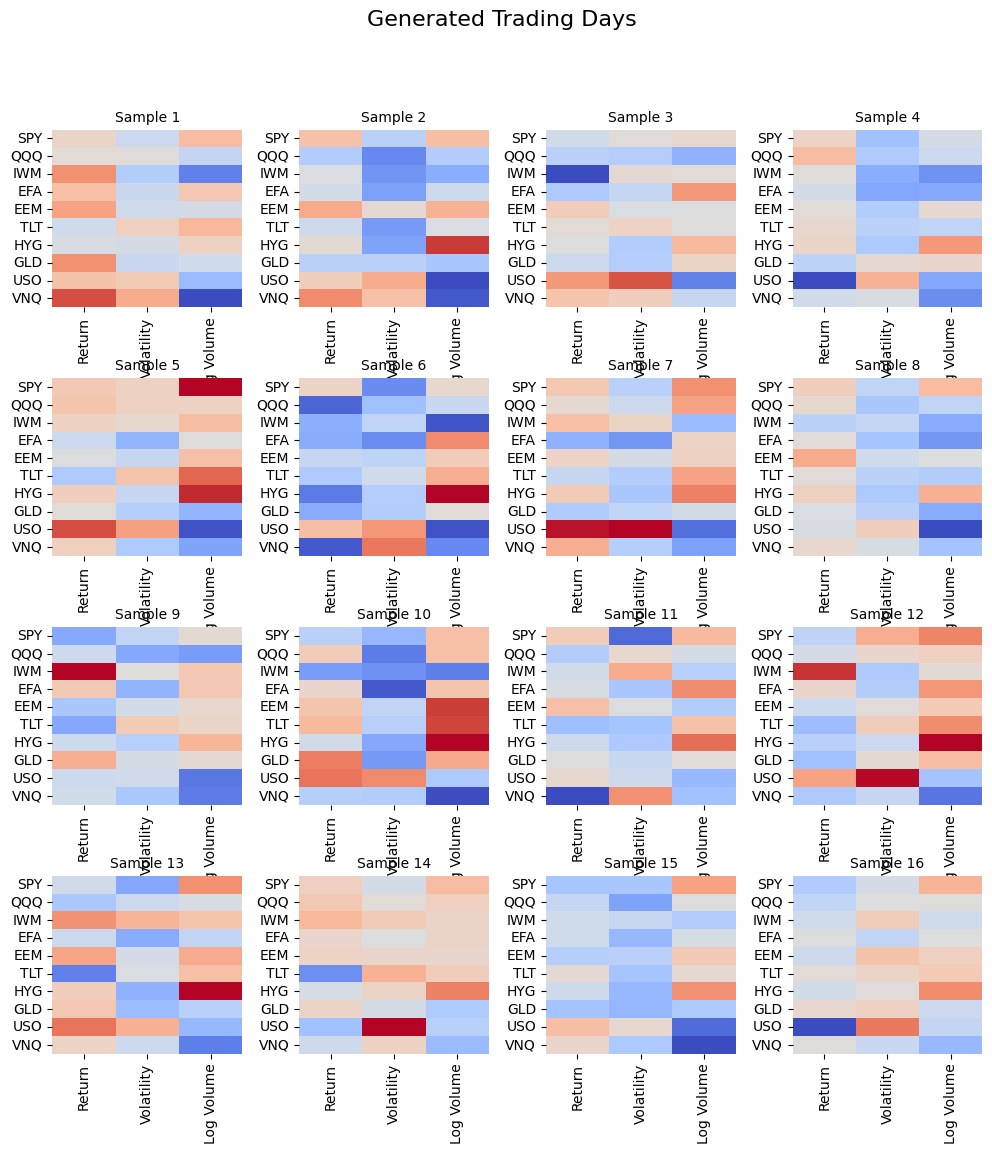

In [ ]:
# Let's visualize 16 generated trading days

feature_names = ["Return", "Volatility", "Log Volume"]

fig = plt.figure(figsize=(12, 12))
gs = GridSpec(4, 4, wspace=0.3, hspace=0.4)

for i in range(16):

    ax = fig.add_subplot(gs[i])

    sns.heatmap(
        x_samples[i],
        cmap="coolwarm",
        center=0,
        cbar=False,
        xticklabels=feature_names,
        yticklabels=tickers,
        ax=ax
    )

    ax.set_title(f"Sample {i+1}", fontsize=10)

plt.suptitle("Generated Trading Days", fontsize=16)
plt.tight_layout()

let's also compare them at the level of the feature's histograms

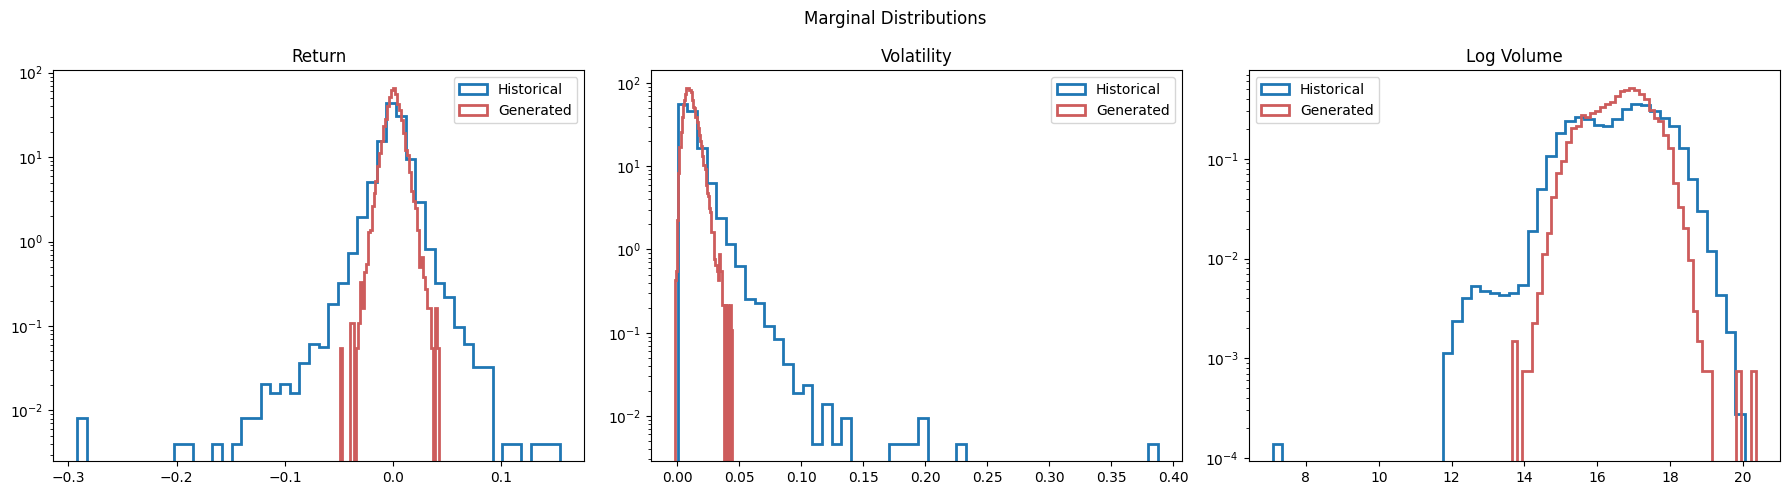

In [ ]:
real_data = financial_data.reshape(-1, n_features)
x_samples_scaled = x_samples * std_per_feature + mean_per_feature
generated_data = x_samples_scaled.reshape(-1, n_features)

feature_names = ["Return", "Volatility", "Log Volume"]

fig, ax = plt.subplots(1, 3, figsize=(18,5))

for i in range(3):

    ax[i].hist(
        real_data[:, i],
        bins=50,
        density=True,
        histtype="step",
        linewidth=2,
        label="Historical"
    )

    ax[i].hist(
        generated_data[:, i],
        bins=50,
        density=True,
        histtype="step",
        linewidth=2,
        label="Generated",
        color="indianred"
    )

    ax[i].set_title(feature_names[i])
    ax[i].set_yscale("log")
    ax[i].legend()

plt.suptitle("Marginal Distributions")
plt.tight_layout()



Como pueden observar, la media de cada una de las distribuciones marginales de las variables está muy bien aproximada. Sin embargo, parece ser que el riesgo de las colas de la distribución podría mejorar. ¿Qué se podría modificar en el flujo de trabajo del código para poder aumentar el ajustte en las colas?